# LiH: MLP Training (2000 epochs)

Trains an MLP on 6-qubit LiH data and compares with RF.
Matches H₂ training_MLP.ipynb structure.

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

print('All imports OK')

All imports OK


## 1. Load Data and Build Features

In [2]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = meta['n_qubits']

backend = FakeJakartaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']
ALL_OBS = list(range(1, len(PAULI_LABELS)))

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_props[q]['T1']*active, qubit_props[q]['T2']*active,
                      qubit_props[q]['readout_error']*active])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        nf = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *nf])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

N_TRAIN = 1800
ideal_test = ideal_data[N_TRAIN:]
noisy_test = noisy_data[N_TRAIN:]

X_train_raw, y_train = build_features(noisy_data[:N_TRAIN], ideal_data[:N_TRAIN], ALL_OBS)
X_test_raw, y_test = build_features(noisy_test, ideal_test, ALL_OBS)
baseline_mae = mean_absolute_error(y_test, X_test_raw[:, 0])

print(f'Training: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Baseline (unmitigated) MAE: {baseline_mae:.4f}')

Training: (109800, 33)  |  Test: (12200, 33)
Baseline (unmitigated) MAE: 0.0406


## 2. Train MLP (2000 epochs)

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

n_val = int(0.2 * len(X_train_raw))
idx = np.random.RandomState(42).permutation(len(X_train_raw))
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_tr, y_tr = X_train_raw[train_idx], y_train[train_idx]
X_val, y_val = X_train_raw[val_idx], y_train[val_idx]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test_raw)

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)
Xte = torch.tensor(X_te_sc, dtype=torch.float32)

model = MLP(X_train_raw.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.HuberLoss()

best_val_mae, best_state, no_imp = float('inf'), None, 0
train_hist, val_hist = [], []

for epoch in range(2000):
    model.train()
    opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        tr_mae = mean_absolute_error(y_tr, model(Xt).numpy().ravel())
        val_mae = mean_absolute_error(y_val, model(Xv).numpy().ravel())
    train_hist.append(tr_mae)
    val_hist.append(val_mae)
    if val_mae < best_val_mae - 1e-6:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 25: break

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    mlp_test_pred = model(Xte).numpy().ravel()

mlp_test_mae = mean_absolute_error(y_test, mlp_test_pred)

print(f'MLP: {model.count_params()} parameters')
print(f'Stopped at epoch {len(train_hist)}')
print(f'\nMLP Test MAE:          {mlp_test_mae:.4f}  ({baseline_mae/mlp_test_mae:.1f}x improvement)')
print(f'Baseline (unmitigated): {baseline_mae:.4f}')

MLP: 2369 parameters
Stopped at epoch 1593

MLP Test MAE:          0.0121  (3.4x improvement)
Baseline (unmitigated): 0.0406


## 3. Training Curve

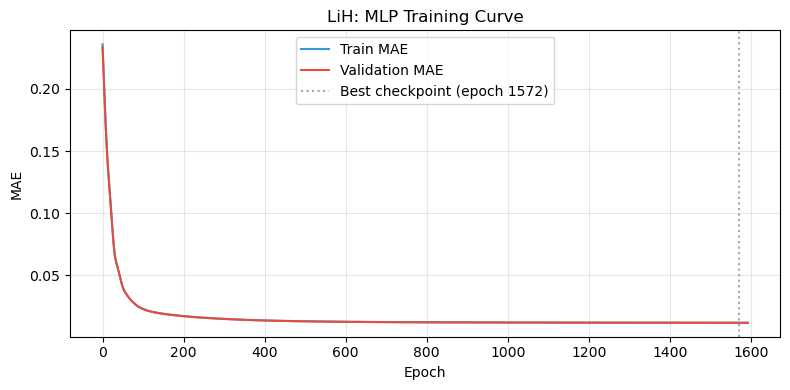

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_hist, label='Train MAE', color='#3498db')
ax.plot(val_hist, label='Validation MAE', color='#e74c3c')
best_epoch = np.argmin(val_hist)
ax.axvline(best_epoch, color='gray', linestyle=':', alpha=0.7,
           label=f'Best checkpoint (epoch {best_epoch+1})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('LiH: MLP Training Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lih_mlp_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Compare RF vs MLP

In [5]:
rf = joblib.load('lih_rf_mlqem.joblib')
rf_test_pred = rf.predict(X_test_raw)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

print('=' * 56)
print(f'  LiH (6 qubits, {len(ALL_OBS)} non-trivial observables)')
print(f'  Unmitigated MAE : {baseline_mae:.4f}')
print(f'  RF MAE          : {rf_test_mae:.4f}  ({baseline_mae/rf_test_mae:.1f}x improvement)')
print(f'  MLP MAE         : {mlp_test_mae:.4f}  ({baseline_mae/mlp_test_mae:.1f}x improvement)')
print(f'  Winner          : {"RF" if rf_test_mae < mlp_test_mae else "MLP"}')
print('=' * 56)

  LiH (6 qubits, 61 non-trivial observables)
  Unmitigated MAE : 0.0406
  RF MAE          : 0.0135  (3.0x improvement)
  MLP MAE         : 0.0121  (3.4x improvement)
  Winner          : MLP


## 5. Per-Observable Comparison

In [6]:
print(f'{"Observable":<10} {"Unmitigated":>12} {"RF":>10} {"MLP":>10}')
print('-' * 44)

for obs_idx in ALL_OBS[:10]:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats_raw = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ]).astype(np.float32)

    ideal_vals = ideal_test[:, obs_idx]
    noisy_vals = noisy_test[:, obs_idx]
    rf_vals = rf.predict(feats_raw)
    feats_sc = scaler.transform(feats_raw)
    with torch.no_grad():
        mlp_vals = model(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

    print(f'{label:<10} {mean_absolute_error(ideal_vals, noisy_vals):>12.4f} '
          f'{mean_absolute_error(ideal_vals, rf_vals):>10.4f} '
          f'{mean_absolute_error(ideal_vals, mlp_vals):>10.4f}')

print(f'\n... ({len(ALL_OBS)} observables total)')

Observable  Unmitigated         RF        MLP
--------------------------------------------
IIIIIZ           0.0304     0.0115     0.0114
IIIIYY           0.0339     0.0114     0.0106
IIIIXX           0.0405     0.0121     0.0107
IIIIZI           0.0285     0.0117     0.0104
IIIZII           0.0199     0.0116     0.0116
IIZIII           0.0234     0.0110     0.0116
IYYIII           0.0552     0.0122     0.0115
IXXIII           0.0457     0.0123     0.0121
IZIIII           0.0335     0.0143     0.0124
ZIIIII           0.0418     0.0144     0.0125

... (61 observables total)


## 6. Energy Reconstruction

In [7]:
coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_test @ coeffs
E_unm = noisy_test @ coeffs

rf_corrected = noisy_test.copy()
mlp_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    rf_corrected[:, obs_idx] = rf.predict(feats)
    feats_sc = scaler.transform(feats)
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

rf_corrected[:, 0] = 1.0
mlp_corrected[:, 0] = 1.0
E_rf = rf_corrected @ coeffs
E_mlp = mlp_corrected @ coeffs

print(f'Energy MAE on 200 test θ values:')
print(f'  Unmitigated : {mean_absolute_error(E_ideal, E_unm):.5f} Ha')
print(f'  RF          : {mean_absolute_error(E_ideal, E_rf):.5f} Ha')
print(f'  MLP         : {mean_absolute_error(E_ideal, E_mlp):.5f} Ha')
print(f'\n  Chemical accuracy: 0.00160 Ha')

Energy MAE on 200 test θ values:
  Unmitigated : 0.01202 Ha
  RF          : 0.00477 Ha
  MLP         : 0.00462 Ha

  Chemical accuracy: 0.00160 Ha
